# Mini Project 4
### Part II
Finally, perform a statistical linear regression (not for prediction) with the number of rentals as the
independent variable and the amount of money spent as the dependent variable. Report your results
and your conclusions. 

I was personally having tecnological difficulty establishing a connection between MySQL and Python 
with the SQL Connector, so I queried for the two variables called for in the simple linear regression
and saved the output from SQL to a csv file. Then I performed the regression calling from the csv instead 
of the SQL file. 

In [16]:
#Relavent Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error , r2_score
import seaborn as sns

In [17]:
#Importing the data
data = pd.read_csv('MP4_NewData.csv')
data.head()

,country,num_rentals,total_spent
0,India,1572,6628.28
1,China,1426,5798.74
2,United States,968,4110.32
3,Japan,825,3470.75
4,Mexico,796,3307.04


In [26]:
data.value_counts

<bound method DataFrame.value_counts of             country  num_rentals  total_spent
0             India         1572      6628.28
1             China         1426      5798.74
2     United States          968      4110.32
3             Japan          825      3470.75
4            Mexico          796      3307.04
..              ...          ...          ...
103         Tunisia           23        78.77
104           Tonga           18        73.82
105       Lithuania           24        73.76
106  American Samoa           20        71.80
107     Afghanistan           18        67.82

[108 rows x 3 columns]>

In [27]:
#Establishing the variables for the regression
X = data[['num_rentals']]
y = data['total_spent']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.20, random_state=42)
X_train.info()

<class 'pandas.DataFrame'>
Index: 86 entries, 64 to 102
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   num_rentals  86 non-null     int64
dtypes: int64(1)
memory usage: 1.3 KB


In [20]:
model = LinearRegression()
model.fit(X_train.values, y_train.values)

y_pred = model.predict(X_test.values)

In [21]:
mse = mean_squared_error(y_test, y_pred)
print("MSE: ", mse)

rmse = np.sqrt(mse)
print("RMSE: ", rmse)

r2 = r2_score(y_test, y_pred)
print("r2: ", r2)

MSE:  678.5015839153069
RMSE:  26.04806295898616
r2:  0.9996842721318164


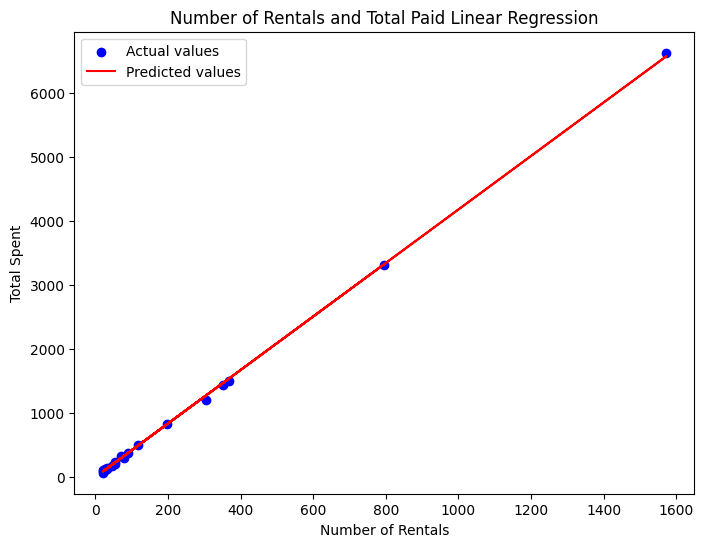

In [15]:
#Graphing actual values on the predicted line. 
plt.figure(figsize=(8,6))
plt.scatter(X_test, y_test, color="blue", label="Actual values")
plt.plot(X_test, y_pred, color="red", label="Predicted values")
plt.xlabel("Number of Rentals")
plt.ylabel("Total Spent")
plt.title("Number of Rentals and Total Paid Linear Regression")
plt.legend()
plt.show()

In [23]:
#From this simple regression, the model easily predicts Total Spent from the number of rentals. While an 
#R2 score of .99 would normally be suspicious in a more complex model, it is fair to assume the high score comes from 
#the predictable relationship of more rentals costing more money. 